# Exploración completa de Airbnb Bogotá: MongoDB, solo lectura
Guía del taller, páginas 2–3; rúbrica página 7. **Todas las filas** se recorren con `Extraccion`: Listings se materializa; Reviews y Calendar se procesan en lotes de 10.000 sin concatenación global. No se leen CSV ni se modifica MongoDB. Las conversiones son temporales para EDA, no la etapa formal Transformacion.

Los ejemplos excluyen nombres, comentarios, URLs y host por privacidad. `$` no identifica USD ni COP: se reportan unidades monetarias nominales. `available=f` no significa necesariamente reserva: incluye posibles bloqueos del host. Reviews no equivale directamente a demanda/ocupación. Calendar es horizonte de oferta, no actividad histórica.

In [1]:
from pathlib import Path
import os, sys, json, io, time
from collections import Counter
import importlib.metadata as metadata
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
interprete = ROOT / ('.venv/Scripts/python.exe' if os.name == 'nt' else '.venv/bin/python')
assert Path(sys.executable).absolute() == interprete.absolute(), sys.executable
%matplotlib inline
os.environ['MPLCONFIGDIR'] = str(ROOT / '.venv/eda_cache/matplotlib')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from src.extraccion import Extraccion
from src.analisis import Perfil, convertir, iqr, duplicados, amenities, describir_frecuencias
plt.rcParams.update({'figure.figsize': (8, 4), 'figure.dpi': 90})
inicio = time.monotonic()
resumen = {'config': {'base': os.getenv('MONGO_DB', 'airbnb'), 'batch': 10000,
    'fuente': 'MongoDB solo lectura', 'id_mongo_excluido': True,
    'kernel': sys.executable, 'python': sys.version.split()[0]},
    'versiones': {p: metadata.version(p) for p in ['pandas','numpy','pymongo','matplotlib','nbclient','ipykernel']},
    'colecciones': {}}
ejemplos, infos = {}, {}
longitudes = Counter()
claves = {'Listings':['id'], 'Reviews':['id'], 'Calendar':['listing_id','date']}
publicas = {'Listings':['id','room_type','neighbourhood_cleansed','price','minimum_nights','availability_365'],
 'Reviews':['id','listing_id','date'], 'Calendar':['listing_id','date','available','minimum_nights','maximum_nights']}
with Extraccion(uri=os.getenv('MONGO_URI', 'mongodb://127.0.0.1:27017'), base=resumen['config']['base']) as e:
    for nombre in claves:
        perfil = Perfil()
        partes = []
        meses = Counter(); semanas = Counter(); disponibles = Counter(); denominadores = Counter()
        fechas_min = fechas_max = None
        conversion = Counter()
        frecuencias_cal = {k:Counter() for k in ['minimum_nights','maximum_nights']}
        for lote in e.iterar(nombre, 10000):
            perfil.agregar(lote)
            if nombre not in ejemplos:
                ejemplos[nombre] = lote[publicas[nombre]].head()
                salida = io.StringIO(); lote.info(buf=salida); infos[nombre] = salida.getvalue()
            if nombre == 'Listings':
                partes.append(lote)
            else:
                fechas, c = convertir(lote['date'], 'fecha')
                conversion.update({'fecha_'+k:v for k,v in c.items()})
                if fechas.notna().any():
                    mn, mx = fechas.min().strftime('%Y-%m-%d'), fechas.max().strftime('%Y-%m-%d')
                    fechas_min = min(fechas_min or mn, mn); fechas_max = max(fechas_max or mx, mx)
                mes = fechas.dt.strftime('%Y-%m')
                semana = fechas.dt.to_period('W-SUN').astype('string').where(fechas.notna())
                meses.update(mes.dropna().value_counts().to_dict())
                semanas.update(semana.dropna().value_counts().to_dict())
                if nombre == 'Calendar':
                    flags, c = convertir(lote['available'], 'booleano')
                    conversion.update({'available_'+k:v for k,v in c.items()})
                    denominadores.update(mes[flags.notna()].dropna().value_counts().to_dict())
                    disponibles.update(mes[flags.eq(1)].dropna().value_counts().to_dict())
                    for campo in ['minimum_nights','maximum_nights']:
                        v,c = convertir(lote[campo])
                        conversion.update({campo+'_'+k:x for k,x in c.items()})
                        conversion[campo+'_negativos'] += int(v.lt(0).sum())
                        frecuencias_cal[campo].update({float(k):int(x) for k,x in v.dropna().value_counts().items()})
                else:
                    lens = lote['comments'].astype('string').str.len()
                    longitudes.update({int(k):int(v) for k,v in lens.dropna().value_counts().items()})
        p = perfil.resultado()
        esperado = e.db[nombre].count_documents({})
        assert p['filas'] == esperado
        assert p['n_columnas'] == {'Listings':90,'Reviews':6,'Calendar':5}[nombre]
        assert p['filas'] == {'Listings':19187,'Reviews':527731,'Calendar':7003255}[nombre]
        assert '_id' not in p['columnas']
        p['mongo_count'] = esperado
        p['duplicados_clave'] = duplicados(e.db[nombre], claves[nombre])
        key_missing = sum(p['columnas'][k].get(x,0) for k in claves[nombre] for x in ['null','vacio','ausente','marcador_candidato'])
        p['claves_ausencia_o_candidatos'] = key_missing
        if p['duplicados_clave']['exceso'] == 0 and key_missing == 0:
            p['duplicados_fila_completa'] = 0
            p['prueba_duplicados'] = 'Clave de negocio unica y presente implica filas completas unicas, excluyendo _id.'
        else:
            raise RuntimeError('Duplicados o claves dudosas: comparar conflictos antes de concluir')
        if nombre == 'Listings':
            listings = pd.concat(partes, ignore_index=True)
        else:
            p['conversiones'] = dict(conversion)
            p['fecha_min'] = fechas_min; p['fecha_max'] = fechas_max
            p['meses'] = dict(sorted(meses.items())); p['semanas'] = dict(sorted(semanas.items()))
            if nombre == 'Calendar':
                p['descriptivos_noches'] = {k:describir_frecuencias(v) for k,v in frecuencias_cal.items()}
                p['disponibilidad_mes'] = {m:{'total_fechado':int(meses[m]), 'flags_validos':int(denominadores[m]),
                    'disponibles':int(disponibles[m]), 'porcentaje':100*disponibles[m]/denominadores[m] if denominadores[m] else None} for m in sorted(meses)}
        resumen['colecciones'][nombre] = p
        print(nombre, p['filas'], 'filas completas;', p['n_columnas'], 'columnas;', p['duplicados_clave'])

Listings 19187 filas completas; 90 columnas; {'grupos': 0, 'exceso': 0, 'filas': 0}


Reviews 527731 filas completas; 6 columnas; {'grupos': 0, 'exceso': 0, 'filas': 0}


Calendar 7003255 filas completas; 5 columnas; {'grupos': 0, 'exceso': 0, 'filas': 0}


## Estructura y faltantes por columna
`head()` e `info()` corresponden **al primer lote (muestra)**. El perfil que sigue sí cubre la colección entera: tipos Python por columna y ausencia estructural/null, strings vacíos/whitespace y candidatos `NA/N/A/NULL/NAN/NONE` separados. Marcador candidato no es ausencia confirmada. Un `isna=0` no demuestra completitud.

Las tablas de perfil muestran **todas** las columnas (incluidas aquellas no presentadas en el head público). El `_id` artificial de MongoDB se excluye de estructura y pruebas de duplicación.

In [2]:
for nombre, p in resumen['colecciones'].items():
    display(Markdown(f"### {nombre}: {p['filas']:,} × {p['n_columnas']} (sin _id)"))
    display(ejemplos[nombre])
    print('info del primer lote, no perfil completo:'); print(infos[nombre])
    with pd.option_context('display.max_rows', 100, 'display.max_columns', 10):
        display(pd.DataFrame(p['columnas']).T.fillna(0))
    display(Markdown(f"Duplicados exactos de clave: **{p['duplicados_clave']}**. {p['prueba_duplicados']} No es necesario eliminar duplicados. La unicidad de `_id` no se usa como prueba."))

### Listings: 19,187 × 90 (sin _id)

,id,room_type,neighbourhood_cleansed,price,minimum_nights,availability_365
0,27841,Entire home/apt,Chapinero,"$284,294.01",28,82
1,65762,Entire home/apt,Candelaria,"$215,000.00",1,236
2,138660,Entire home/apt,Chapinero,"$99,196.10",30,303
3,178850,Entire home/apt,Usaquen,"$179,910.67",30,353
4,289669,Private room,Teusaquillo,"$82,260.75",4,222


info del primer lote, no perfil completo:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   id                                            10000 non-null  str  
 1   listing_url                                   10000 non-null  str  
 2   scrape_id                                     10000 non-null  str  
 3   last_scraped                                  10000 non-null  str  
 4   source                                        10000 non-null  str  
 5   name                                          10000 non-null  str  
 6   description                                   10000 non-null  str  
 7   neighborhood_overview                         10000 non-null  str  
 8   picture_url                                   10000 non-null  str  
 9   host_id                                       10000 n

,ausente,marcador_candidato,null,tipo:str,vacio
accommodates,0,0,0,19187,0
amenities,0,0,0,19187,0
availability_30,0,0,0,19187,0
availability_365,0,0,0,19187,0
availability_60,0,0,0,19187,0
availability_90,0,0,0,19187,0
availability_eoy,0,0,0,19187,0
bathrooms,0,0,0,19187,1066
bathrooms_text,0,0,0,19187,29
bedrooms,0,0,0,19187,2959


Duplicados exactos de clave: **{'grupos': 0, 'exceso': 0, 'filas': 0}**. Clave de negocio unica y presente implica filas completas unicas, excluyendo _id. No es necesario eliminar duplicados. La unicidad de `_id` no se usa como prueba.

...

### Calendar: 7,003,255 × 5 (sin _id)

,listing_id,date,available,minimum_nights,maximum_nights
0,15410909,2026-06-22,f,2,1125
1,15410909,2026-06-23,f,2,1125
2,15410909,2026-06-24,f,2,1125
3,15410909,2026-06-25,t,2,1125
4,15410909,2026-06-26,t,2,1125


info del primer lote, no perfil completo:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   listing_id      10000 non-null  str  
 1   date            10000 non-null  str  
 2   available       10000 non-null  str  
 3   minimum_nights  10000 non-null  str  
 4   maximum_nights  10000 non-null  str  
dtypes: str(5)
memory usage: 390.8 KB



,ausente,marcador_candidato,null,tipo:str,vacio
available,0,0,0,7003255,0
date,0,0,0,7003255,0
listing_id,0,0,0,7003255,0
maximum_nights,0,0,0,7003255,0
minimum_nights,0,0,0,7003255,0


Duplicados exactos de clave: **{'grupos': 0, 'exceso': 0, 'filas': 0}**. Clave de negocio unica y presente implica filas completas unicas, excluyendo _id. No es necesario eliminar duplicados. La unicidad de `_id` no se usa como prueba.

## Listings: descriptivos, conversiones e IQR
Precio admite dólar opcional, punto decimal y comas de miles validadas; no coma decimal. Cada conversión informa faltantes, invalidos y no finitos, conservando originales. IDs son strings opacos, no variables numéricas. IQR se calcula sobre todos los valores finitos; cercas estrictas 1,5×IQR, sin eliminar extremos. Un atípico no demuestra error.

,validos,faltantes,invalidos,no_finitos
price,18992,195,0,0
minimum_nights,19183,4,0,0
availability_365,19187,0,0,0
accommodates,19187,0,0,0
bedrooms,16228,2959,0,0
beds,18896,291,0,0
number_of_reviews,19187,0,0,0
review_scores_rating,14922,4265,0,0


,price,minimum_nights,availability_365,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating
count,1.899200e+04,19183.000000,19187.000000,19187.000000,16228.000000,18896.000000,19187.000000,14922.000000
mean,4.460266e+05,6.979878,306.947725,3.105697,1.540670,1.945703,27.504612,4.703524
std,8.829057e+06,10.993985,82.073601,2.088394,1.601175,2.094844,74.004586,0.469821
min,1.918111e+04,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,1.100000e+05,1.000000,269.000000,2.000000,1.000000,1.000000,1.000000,4.640000
50%,1.614600e+05,1.000000,349.000000,2.000000,1.000000,1.000000,8.000000,4.830000
75%,2.303464e+05,3.000000,363.000000,4.000000,2.000000,2.000000,31.000000,4.980000
max,4.481766e+08,32.000000,365.000000,16.000000,50.000000,50.000000,6162.000000,5.000000


,n,q1,q3,inferior,superior,atipicos
price,18992.0,110000.0,230346.375,-70519.5625,410865.9375,1410.0
minimum_nights,19183.0,1.0,3.000,-2.0000,6.0000,4053.0
availability_365,19187.0,269.0,363.000,128.0000,504.0000,1129.0


{'price_negativo': 0,
 'price_cero': 0,
 'minimum_nights_no_positivo': 0,
 'availability_fuera_0_365': 0}

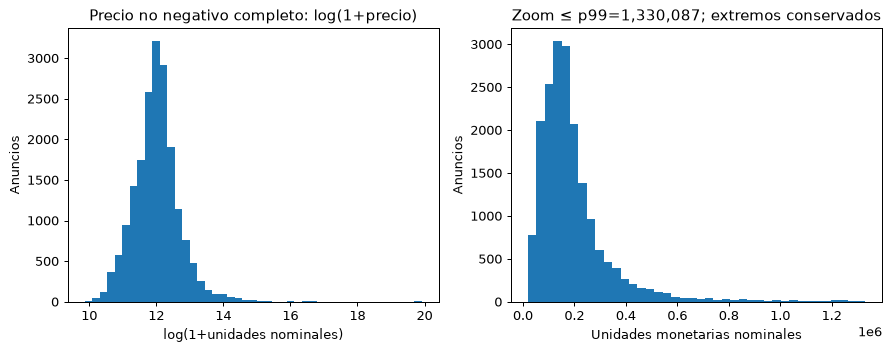

**IQR completo:** price: 1,410/18,992 atípicos; minimum_nights: 4,053/19,183 atípicos; availability_365: 1,129/19,187 atípicos. Revisar extremos y estancias largas antes de fijar reglas; no recortar automáticamente.

{'last_scraped': {'validos': 19187,
  'faltantes': 0,
  'invalidos': 0,
  'no_finitos': 0,
  'min': '2026-06-21',
  'max': '2026-06-22'},
 'calendar_last_scraped': {'validos': 19187,
  'faltantes': 0,
  'invalidos': 0,
  'no_finitos': 0,
  'min': '2026-06-21',
  'max': '2026-06-22'},
 'first_review': {'validos': 14922,
  'faltantes': 4265,
  'invalidos': 0,
  'no_finitos': 0,
  'min': '2010-10-06',
  'max': '2026-06-21'},
 'last_review': {'validos': 14922,
  'faltantes': 4265,
  'invalidos': 0,
  'no_finitos': 0,
  'min': '2011-10-14',
  'max': '2026-06-21'},
 'price_quote_checkin_date': {'validos': 19184,
  'faltantes': 3,
  'invalidos': 0,
  'no_finitos': 0,
  'min': '2026-06-21',
  'max': '2027-06-18'},
 'price_quote_checkout_date': {'validos': 19184,
  'faltantes': 3,
  'invalidos': 0,
  'no_finitos': 0,
  'min': '2026-06-22',
  'max': '2027-06-21'}}

{'price_quote_total_price': {'validos': 18992,
  'faltantes': 195,
  'invalidos': 0,
  'no_finitos': 0,
  'n_comparables': 18992,
  'iguales_a_price': 9389,
  'descriptivos': {'count': 18992.0,
   'mean': 1934169.4500542334,
   'std': 61940728.87538767,
   'min': 28000.0,
   '25%': 168898.75,
   '50%': 303360.53,
   '75%': 889416.0875,
   'max': 8401450535.74}},
 'price_quote_price_per_night': {'validos': 18992,
  'faltantes': 195,
  'invalidos': 0,
  'no_finitos': 0,
  'n_comparables': 18992,
  'iguales_a_price': 18992,
  'descriptivos': {'count': 18992.0,
   'mean': 446026.5525505476,
   'std': 8829056.710912477,
   'min': 19181.11,
   '25%': 110000.0,
   '50%': 161460.0,
   '75%': 230346.375,
   'max': 448176567.0}}}

Precio: **195** faltantes; media **446,026.55**, mediana **161,460.00**, máximo **448,176,567.00** unidades nominales. La diferencia media–mediana evidencia fuerte asimetría; verificar extremos y cotizaciones antes de categorizar. Snapshot Listings `last_scraped`: **2026-06-21–2026-06-22**. Calendar corresponde al horizonte de oferta de esa captura, no a disponibilidad en tiempo real ni a fechas todas futuras respecto de hoy.

In [3]:
campos = ['price','minimum_nights','availability_365','accommodates','bedrooms','beds','number_of_reviews','review_scores_rating']
numericos = pd.DataFrame(index=listings.index)
conversiones = {}
for campo in campos:
    numericos[campo], conversiones[campo] = convertir(listings[campo], 'precio' if campo == 'price' else 'numero')
outliers = {k:iqr(numericos[k]) for k in ['price','minimum_nights','availability_365']}
resumen['listings_conversiones'] = conversiones
resumen['outliers_iqr'] = outliers
resumen['descriptivos_listings'] = numericos.describe().to_dict()
resumen['dominios'] = {'price_negativo':int(numericos.price.lt(0).sum()), 'price_cero':int(numericos.price.eq(0).sum()),
 'minimum_nights_no_positivo':int(numericos.minimum_nights.le(0).sum()),
 'availability_fuera_0_365':int((numericos.availability_365.lt(0)|numericos.availability_365.gt(365)).sum())}
display(pd.DataFrame(conversiones).T); display(numericos.describe()); display(pd.DataFrame(outliers).T); display(resumen['dominios'])
precio = numericos.price.dropna()
fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].hist(np.log1p(precio[precio.ge(0)]), bins=45)
axs[0].set(title='Precio no negativo completo: log(1+precio)', xlabel='log(1+unidades nominales)', ylabel='Anuncios')
limite = precio.quantile(.99)
axs[1].hist(precio[precio.le(limite)], bins=40)
axs[1].set(title=f'Zoom ≤ p99={limite:,.0f}; extremos conservados', xlabel='Unidades monetarias nominales', ylabel='Anuncios')
plt.tight_layout(); plt.show()
display(Markdown('**IQR completo:** ' + '; '.join(f"{k}: {v['atipicos']:,}/{v['n']:,} atípicos" for k,v in outliers.items()) + '. Revisar extremos y estancias largas antes de fijar reglas; no recortar automáticamente.'))
resumen['listings_fechas'] = {}
for campo in ['last_scraped','calendar_last_scraped','first_review','last_review','price_quote_checkin_date','price_quote_checkout_date']:
    f,c = convertir(listings[campo], 'fecha')
    resumen['listings_fechas'][campo] = {**c, 'min':f.min().strftime('%Y-%m-%d') if f.notna().any() else None, 'max':f.max().strftime('%Y-%m-%d') if f.notna().any() else None}
display(resumen['listings_fechas'])
resumen['cotizaciones'] = {}
for campo in ['price_quote_total_price','price_quote_price_per_night']:
    v,c = convertir(listings[campo], 'precio')
    validos = v.notna() & numericos.price.notna()
    resumen['cotizaciones'][campo] = {**c, 'n_comparables':int(validos.sum()), 'iguales_a_price':int(v[validos].eq(numericos.price[validos]).sum()), 'descriptivos':v.describe().to_dict()}
display(resumen['cotizaciones'])
display(Markdown(f"Precio: **{conversiones['price']['faltantes']:,}** faltantes; media **{precio.mean():,.2f}**, mediana **{precio.median():,.2f}**, máximo **{precio.max():,.2f}** unidades nominales. La diferencia media–mediana evidencia fuerte asimetría; verificar extremos y cotizaciones antes de categorizar. Snapshot Listings `last_scraped`: **{resumen['listings_fechas']['last_scraped']['min']}–{resumen['listings_fechas']['last_scraped']['max']}**. Calendar corresponde al horizonte de oferta de esa captura, no a disponibilidad en tiempo real ni a fechas todas futuras respecto de hoy."))


,N,N_precio,mediana
room_type,,,
Entire home/apt,13865,13744,182589.0
Private room,5172,5098,91295.0
Shared room,117,117,41453.0
Hotel room,33,33,193048.0


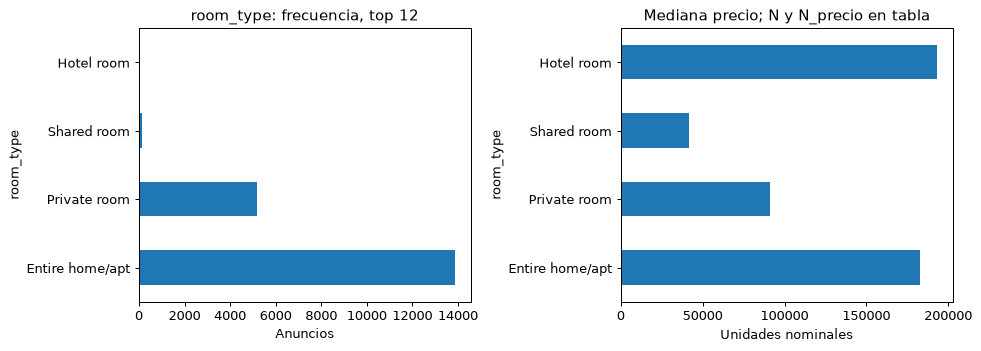

La categoría más frecuente es **Entire home/apt**, con **13,865** anuncios; mediana de precio válido **182,589.00**. Comparar tamaños y mezcla de alojamientos; diferencias no prueban efectos causales del barrio o tipo.

,N,N_precio,mediana
neighbourhood_cleansed,,,
Chapinero,5097,5056,199111.870
Usaquen,3582,3542,194001.000
Teusaquillo,2779,2763,136479.000
Santa Fe,1453,1437,149562.660
Suba,1274,1255,136941.330
Engativa,1211,1199,112347.000
Barrios Unidos,1036,1028,142647.500
Fontibon,969,956,136942.000
Candelaria,700,697,136941.240


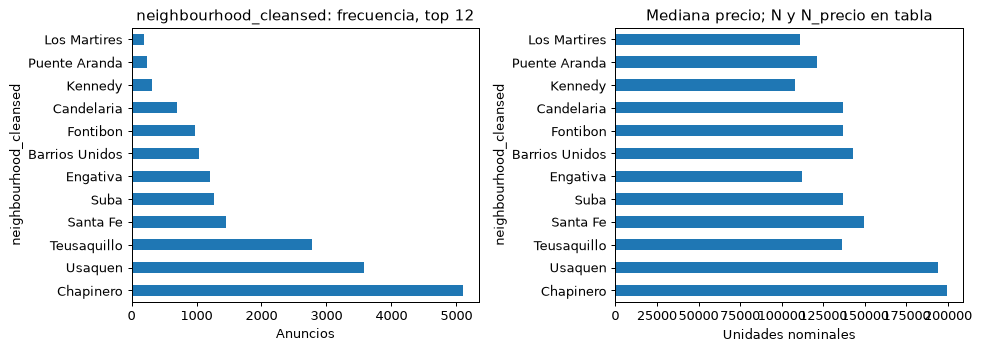

La categoría más frecuente es **Chapinero**, con **5,097** anuncios; mediana de precio válido **199,111.87**. Comparar tamaños y mezcla de alojamientos; diferencias no prueban efectos causales del barrio o tipo.

In [4]:
resumen['categorias'] = {}
for campo in ['room_type', 'neighbourhood_cleansed']:
    tabla = listings.assign(precio_eda=numericos.price).groupby(campo, dropna=False).agg(N=('id','size'), N_precio=('precio_eda','count'), mediana=('precio_eda','median')).sort_values('N', ascending=False)
    resumen['categorias'][campo] = tabla.reset_index().to_dict('records')
    display(tabla)
    top = tabla.head(12)
    fig, axs = plt.subplots(1,2,figsize=(11,4))
    top.N.plot.barh(ax=axs[0], title=f'{campo}: frecuencia, top 12')
    top.mediana.plot.barh(ax=axs[1], title='Mediana precio; N y N_precio en tabla')
    axs[0].set_xlabel('Anuncios'); axs[1].set_xlabel('Unidades nominales')
    plt.tight_layout(); plt.show()
    display(Markdown(f"La categoría más frecuente es **{tabla.index[0]}**, con **{int(tabla.N.iloc[0]):,}** anuncios; mediana de precio válido **{tabla.mediana.iloc[0]:,.2f}**. Comparar tamaños y mezcla de alojamientos; diferencias no prueban efectos causales del barrio o tipo."))

## Correlaciones descriptivas, no causalidad
Pearson y Spearman pandas usan casos válidos por par; se informa N por par. No se imputan faltantes ni se eliminan outliers. Pearson puede ser sensible a extremos; Spearman describe asociación de rangos, no causa ni ocupación.

,price,minimum_nights,availability_365,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating
price,1.000000,-0.012223,-0.025771,0.001299,-0.002086,-0.003072,-0.008366,-0.001622
minimum_nights,-0.012223,1.000000,-0.067517,-0.093016,0.057163,-0.027357,-0.137968,0.024090
availability_365,-0.025771,-0.067517,1.000000,0.001960,0.000013,0.005841,-0.030827,-0.086808
accommodates,0.001299,-0.093016,0.001960,1.000000,0.529943,0.678308,0.026092,-0.018789
bedrooms,-0.002086,0.057163,0.000013,0.529943,1.000000,0.735093,0.004036,-0.094966
beds,-0.003072,-0.027357,0.005841,0.678308,0.735093,1.000000,0.019031,-0.068115
number_of_reviews,-0.008366,-0.137968,-0.030827,0.026092,0.004036,0.019031,1.000000,0.072616
review_scores_rating,-0.001622,0.024090,-0.086808,-0.018789,-0.094966,-0.068115,0.072616,1.000000


,price,minimum_nights,availability_365,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating
price,1.000000,-0.177948,-0.042889,0.501966,0.318959,0.364588,0.102235,0.054620
minimum_nights,-0.177948,1.000000,-0.087868,-0.071377,0.168701,0.016798,-0.210902,0.166666
availability_365,-0.042889,-0.087868,1.000000,-0.103343,-0.069665,-0.099832,-0.257056,-0.112560
accommodates,0.501966,-0.071377,-0.103343,1.000000,0.655250,0.777589,0.141417,-0.017744
bedrooms,0.318959,0.168701,-0.069665,0.655250,1.000000,0.691813,-0.037573,-0.003761
beds,0.364588,0.016798,-0.099832,0.777589,0.691813,1.000000,0.077361,0.006996
number_of_reviews,0.102235,-0.210902,-0.257056,0.141417,-0.037573,0.077361,1.000000,-0.122451
review_scores_rating,0.054620,0.166666,-0.112560,-0.017744,-0.003761,0.006996,-0.122451,1.000000


,price,minimum_nights,availability_365,accommodates,bedrooms,beds,number_of_reviews,review_scores_rating
price,18992,18988,18992,18992,16085,18703,18992,14859
minimum_nights,18988,19183,19183,19183,16224,18892,19183,14918
availability_365,18992,19183,19187,19187,16228,18896,19187,14922
accommodates,18992,19183,19187,19187,16228,18896,19187,14922
bedrooms,16085,16224,16228,16228,16228,15947,16228,13082
beds,18703,18892,18896,18896,15947,18896,18896,14699
number_of_reviews,18992,19183,19187,19187,16228,18896,19187,14922
review_scores_rating,14859,14918,14922,14922,13082,14699,14922,14922


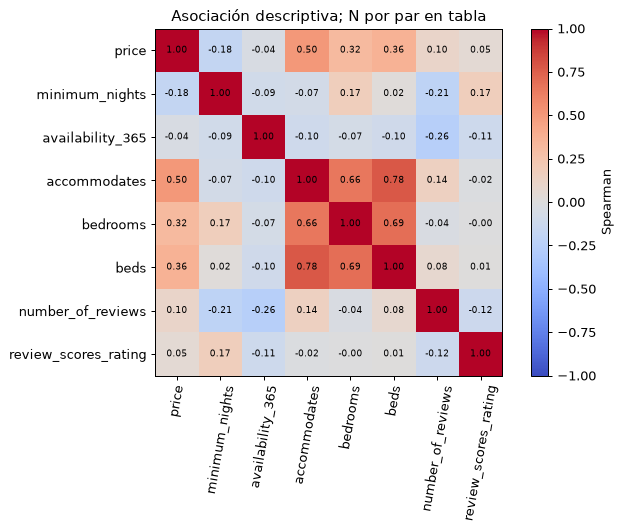

La asociación absoluta más fuerte seleccionada es **beds–accommodates**, Spearman **0.778**, N=18,896. Puede reflejar composición y causas comunes; no identifica causalidad.

In [5]:
pearson = numericos.corr(method='pearson')
spearman = numericos.corr(method='spearman')
npares = numericos.notna().astype(int).T @ numericos.notna().astype(int)
resumen['correlaciones'] = {'pearson':pearson.to_dict(), 'spearman':spearman.to_dict(), 'n_pares':npares.to_dict()}
display(pearson); display(spearman); display(npares)
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(spearman, vmin=-1,vmax=1,cmap='coolwarm')
ax.set_xticks(range(len(campos)), campos, rotation=80); ax.set_yticks(range(len(campos)),campos)
for i in range(len(campos)):
    for j in range(len(campos)): ax.text(j,i,f'{spearman.iloc[i,j]:.2f}',ha='center',va='center',fontsize=7)
fig.colorbar(im, ax=ax, label='Spearman'); ax.set_title('Asociación descriptiva; N por par en tabla'); plt.tight_layout(); plt.show()
pares = [(abs(spearman.iloc[i,j]),campos[i],campos[j],float(spearman.iloc[i,j]),int(npares.iloc[i,j])) for i in range(len(campos)) for j in range(i) if pd.notna(spearman.iloc[i,j])]
_, a,b,r,n = max(pares)
display(Markdown(f'La asociación absoluta más fuerte seleccionada es **{a}–{b}**, Spearman **{r:.3f}**, N={n:,}. Puede reflejar composición y causas comunes; no identifica causalidad.'))

## Reviews y Calendar: series completas, no muestras
Se acumulan todas las fechas válidas. Meses extremos pueden tener cobertura parcial: comparar exposición antes de inferir tendencias. Las semanas se representan como intervalos lunes–domingo y se conservan completas en JSON. Calendar **no tiene price**: no se inventa su distribución. Reviews describe fechas y longitud de comentarios, sin mostrar textos privados.

**Reviews**: 2010-10-06 a 2026-06-21; extremos con cobertura parcial potencial.

{'fecha_validos': 527731,
 'fecha_faltantes': 0,
 'fecha_invalidos': 0,
 'fecha_no_finitos': 0}

,filas por mes
2010-10,1
2010-11,1
2011-01,1
2011-04,1
2011-06,3
...,...
2026-02,16487
2026-03,18438
2026-04,16834
2026-05,18290


,"filas por semana (primeras 8, resto en JSON)"
2010-10-04/2010-10-10,1
2010-11-22/2010-11-28,1
2011-01-17/2011-01-23,1
2011-04-11/2011-04-17,1
2011-05-30/2011-06-05,1
2011-06-20/2011-06-26,1
2011-06-27/2011-07-03,1
2011-07-18/2011-07-24,2


**Calendar**: 2026-06-21 a 2027-06-21; extremos con cobertura parcial potencial.

{'fecha_validos': 7003255,
 'fecha_faltantes': 0,
 'fecha_invalidos': 0,
 'fecha_no_finitos': 0,
 'available_validos': 7003255,
 'available_faltantes': 0,
 'available_invalidos': 0,
 'available_no_finitos': 0,
 'minimum_nights_validos': 7003255,
 'minimum_nights_faltantes': 0,
 'minimum_nights_invalidos': 0,
 'minimum_nights_no_finitos': 0,
 'minimum_nights_negativos': 0,
 'maximum_nights_validos': 7003255,
 'maximum_nights_faltantes': 0,
 'maximum_nights_invalidos': 0,
 'maximum_nights_no_finitos': 0,
 'maximum_nights_negativos': 0}

,n,min,max,media,mediana,q1,q3,inferior,superior,atipicos
minimum_nights,7003255.0,1.0,3.650000e+02,7.254972,2.0,1.0,4.0,-3.5,8.5,1451607.0
maximum_nights,7003255.0,1.0,2.147484e+09,447784.591673,365.0,365.0,1125.0,-775.0,2265.0,1823.0


,filas por mes
2026-06,174141
2026-07,594797
2026-08,594797
2026-09,575610
2026-10,594797
2026-11,575610
2026-12,594797
2027-01,594797
2027-02,537236
2027-03,594797


,"filas por semana (primeras 8, resto en JSON)"
2026-06-15/2026-06-21,1458
2026-06-22/2026-06-28,134309
2026-06-29/2026-07-05,134309
2026-07-06/2026-07-12,134309
2026-07-13/2026-07-19,134309
2026-07-20/2026-07-26,134309
2026-07-27/2026-08-02,134309
2026-08-03/2026-08-09,134309


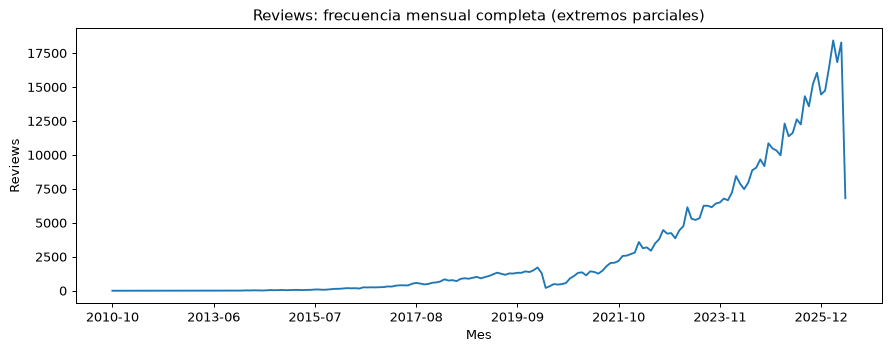

{'n': 527731,
 'min': 1.0,
 'max': 5632.0,
 'media': 160.6935199940879,
 'mediana': 103.0,
 'q1': 45.0,
 'q3': 206.0,
 'inferior': -196.5,
 'superior': 447.5,
 'atipicos': 35670}

,total_fechado,flags_validos,disponibles,porcentaje
2026-06,174141.0,174141.0,106810.0,61.335355
2026-07,594797.0,594797.0,456400.0,76.732062
2026-08,594797.0,594797.0,515099.0,86.600807
2026-09,575610.0,575610.0,511507.0,88.863467
2026-10,594797.0,594797.0,511561.0,86.005982
2026-11,575610.0,575610.0,518575.0,90.091381
2026-12,594797.0,594797.0,530084.0,89.120154
2027-01,594797.0,594797.0,527871.0,88.748094
2027-02,537236.0,537236.0,478752.0,89.113909
2027-03,594797.0,594797.0,503711.0,84.686204


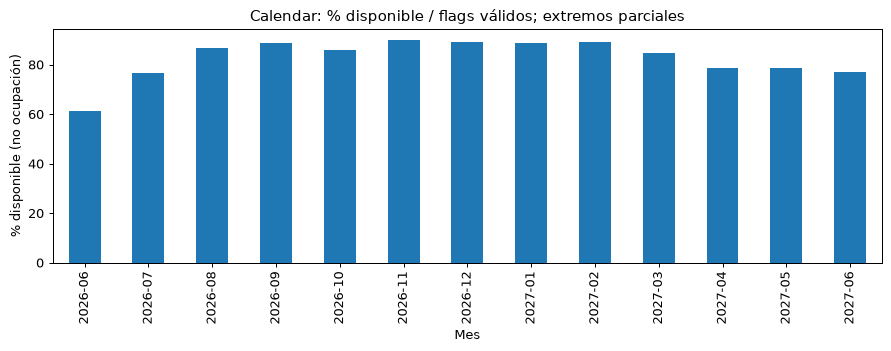

Reviews: **527,731** fechas válidas; pico **2026-03**, **18,438** reviews. No estima reservas. Calendar: **61.34%–90.09%** disponible; comparar denominadores, flags inválidos y cobertura antes de interpretar tendencias.

Calendar minimum_nights: mediana **2**, máximo **365**, **1,451,607/7,003,255** atípicos IQR completos. La regla estadística puede marcar estancias largas legítimas; no eliminar por defecto.

In [6]:
for nombre in ['Reviews','Calendar']:
    p = resumen['colecciones'][nombre]
    display(Markdown(f"**{nombre}**: {p['fecha_min']} a {p['fecha_max']}; extremos con cobertura parcial potencial."))
    display(p['conversiones'])
    if nombre == 'Calendar': display(pd.DataFrame(p['descriptivos_noches']).T)
    display(pd.Series(p['meses'], name='filas por mes').to_frame())
    display(pd.Series(p['semanas'], name='filas por semana (primeras 8, resto en JSON)').head(8).to_frame())
review_m = pd.Series(resumen['colecciones']['Reviews']['meses'])
review_m.plot(title='Reviews: frecuencia mensual completa (extremos parciales)', ylabel='Reviews', xlabel='Mes', figsize=(10,4)); plt.tight_layout(); plt.show()
total_l = sum(longitudes.values())
resumen['comentarios_longitud'] = describir_frecuencias(longitudes)
display(resumen['comentarios_longitud'])
cal = pd.DataFrame(resumen['colecciones']['Calendar']['disponibilidad_mes']).T
display(cal)
cal.porcentaje.plot.bar(title='Calendar: % disponible / flags válidos; extremos parciales', ylabel='% disponible (no ocupación)', xlabel='Mes', figsize=(10,4)); plt.tight_layout(); plt.show()
display(Markdown(f"Reviews: **{sum(review_m):,}** fechas válidas; pico **{review_m.idxmax()}**, **{review_m.max():,}** reviews. No estima reservas. Calendar: **{cal.porcentaje.min():.2f}%–{cal.porcentaje.max():.2f}%** disponible; comparar denominadores, flags inválidos y cobertura antes de interpretar tendencias."))
noches_cal = resumen['colecciones']['Calendar']['descriptivos_noches']['minimum_nights']
display(Markdown(f"Calendar minimum_nights: mediana **{noches_cal['mediana']:g}**, máximo **{noches_cal['max']:g}**, **{noches_cal['atipicos']:,}/{noches_cal['n']:,}** atípicos IQR completos. La regla estadística puede marcar estancias largas legítimas; no eliminar por defecto."))


## Campos complejos y formatos problemáticos
Amenities se valida como JSON de listas textuales: presencia por anuncio, no repeticiones dentro de una lista. Host está en columnas planas `host_*`, verificadas debajo; no se necesita desanidar un objeto inexistente. Una futura dimensión host requiere validar consistencia por host_id.

{'validos': 19187,
 'invalidos': 0,
 'vacios': 0,
 'top': {'Wifi': 17918,
  'Kitchen': 16838,
  'Hot water': 14088,
  'TV': 13582,
  'Dedicated workspace': 13311,
  'Hangers': 13044,
  'Dishes and silverware': 12024,
  'Cooking basics': 11852,
  'Iron': 11765,
  'Bed linens': 10967,
  'Essentials': 9979,
  'Self check-in': 9920,
  'Microwave': 9499,
  'Long term stays allowed': 9493,
  'Refrigerator': 9403}}

['host_id',
 'host_url',
 'host_profile_id',
 'host_profile_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified']

{'price_quote_checkin_date': {'ausente': 0,
  'marcador_candidato': 0,
  'null': 0,
  'tipo:str': 19187,
  'vacio': 3},
 'price_quote_checkout_date': {'ausente': 0,
  'marcador_candidato': 0,
  'null': 0,
  'tipo:str': 19187,
  'vacio': 3},
 'price_quote_total_price': {'ausente': 0,
  'marcador_candidato': 0,
  'null': 0,
  'tipo:str': 19187,
  'vacio': 195},
 'price_quote_price_per_night': {'ausente': 0,
  'marcador_candidato': 0,
  'null': 0,
  'tipo:str': 19187,
  'vacio': 195},
 'price_quote_raw': {'ausente': 0,
  'marcador_candidato': 0,
  'null': 0,
  'tipo:str': 19187,
  'vacio': 3},
 'calendar_updated': {'ausente': 0,
  'marcador_candidato': 0,
  'null': 0,
  'tipo:str': 19187,
  'vacio': 19187}}

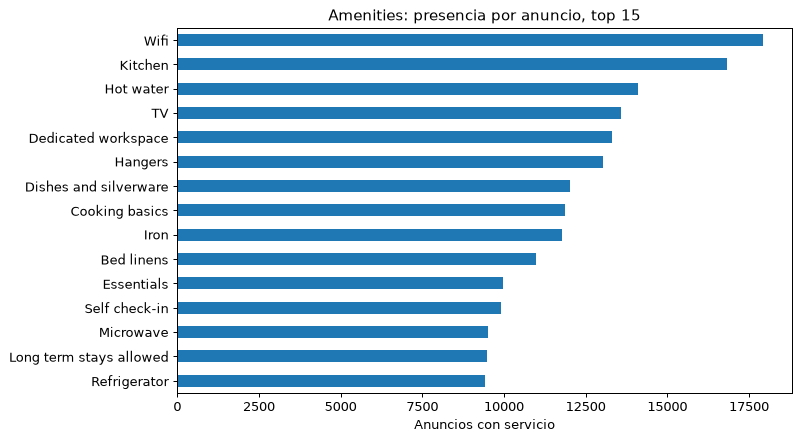

Amenities: **19,187** listas válidas, **0** inválidas, **0** vacías. Tabla puente anuncio–servicio viable, conservando original y sin imponer taxonomía no validada.

**12 columnas totalmente vacías:** calendar_updated, host_acceptance_rate, host_neighbourhood, host_response_rate, host_response_time, host_since, host_thumbnail_url, host_total_listings_count, instant_bookable, neighborhood_overview, neighbourhood, neighbourhood_group_cleansed. No aportan información observada; proponer excluir del modelo analítico o conservar como campos opcionales con procedencia. No imputar datos del host ni `calendar_updated` sin evidencia.

In [7]:
resumen['amenities'] = amenities(listings.amenities)
resumen['host_columnas'] = [c for c in listings if c.startswith('host_')]
resumen['campos_problematicos'] = {c:resumen['colecciones']['Listings']['columnas'][c] for c in listings if c.startswith('price_quote') or c == 'calendar_updated'}
display(resumen['amenities']); display(resumen['host_columnas']); display(resumen['campos_problematicos'])
pd.Series(resumen['amenities']['top']).sort_values().plot.barh(title='Amenities: presencia por anuncio, top 15', xlabel='Anuncios con servicio', figsize=(9,5)); plt.tight_layout(); plt.show()
display(Markdown(f"Amenities: **{resumen['amenities']['validos']:,}** listas válidas, **{resumen['amenities']['invalidos']:,}** inválidas, **{resumen['amenities']['vacios']:,}** vacías. Tabla puente anuncio–servicio viable, conservando original y sin imponer taxonomía no validada."))
p = resumen['colecciones']['Listings']['columnas']
completamente_vacias = [k for k,v in p.items() if v.get('vacio',0) == len(listings)]
resumen['listings_columnas_totalmente_vacias'] = completamente_vacias
display(Markdown(f"**{len(completamente_vacias)} columnas totalmente vacías:** " + ', '.join(completamente_vacias) + '. No aportan información observada; proponer excluir del modelo analítico o conservar como campos opcionales con procedencia. No imputar datos del host ni `calendar_updated` sin evidencia.'))


## Matriz para la futura Transformacion (no aplicada)
| Problema | Transformación propuesta | Justificación | Riesgo / control |
|---|---|---|---|
| Vacíos y marcadores | Reglas por columna y flags de ausencia | isna no detecta vacíos | No convertir NA legítimo indiscriminadamente |
| Precio y price_quote_* | Parsear con auditoría; separar cotizaciones | Formato `$`, miles y punto decimal | Confirmar moneda/significado; no sustituir precio a ciegas |
| Atípicos IQR | Marcar, revisar, mantener fuente | Extremos pueden ser reales | Recortar sesga mercado |
| Fechas | Validar YYYY-MM-DD y derivar mes/semana | Series comparables | Reportar errores, exposición parcial |
| Calendar available | Convertir t/f; resumir con denominador válido | Oferta disponible | f no prueba reserva; reportar inválidos |
| Amenities JSON | Tabla puente para listas válidas | Presencia sin duplicación | Reportar listas exóticas, conservar original |
| Host plano | Dimensión host tras verificar conflictos | Evitar repetición | No asumir consistencia por host_id |
| Texto / calendar_updated | Trim derivado y revisar vacíos | Facilitar comparación | No homogeneizar texto privado ni imputar campo vacío |
| Claves | No eliminar si únicas; comparar conflicto si aparecen duplicados | Agregado exacto MongoDB | _id artificial no prueba negocio |

### Reproducibilidad y límites
JSON estricto con perfiles completos, duplicados, conversiones, outliers, correlaciones y series. Los conteos y columnas se verifican frente a MongoDB y al contrato; un timeout del agregado se propaga, nunca se interpreta como cero. No hay snapshot transaccional: ejecutar sin escritores concurrentes. Listings tiene descriptivos e IQR exactos; Calendar registra parseos y resúmenes sin materializar 7 millones de filas. No se aplican Transformacion, Carga, SQLite, XLSX, informe ni publicación.

Fuentes: guía del taller, páginas 2–3 y 7; [pandas isna](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html), [pandas info](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html), [corr](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html), [to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html); [MongoDB $group](https://www.mongodb.com/docs/manual/reference/operator/aggregation/group/); [Matplotlib hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html); [nbclient](https://nbclient.readthedocs.io/en/latest/client.html).

In [8]:
# NaN estadístico se representa como null, nunca como número inventado.
def sanitizar(x):
    if isinstance(x, dict): return {str(k):sanitizar(v) for k,v in x.items()}
    if isinstance(x, (list,tuple)): return [sanitizar(v) for v in x]
    if isinstance(x, (float,np.floating)) and not np.isfinite(x): return None
    if isinstance(x, np.integer): return int(x)
    return x
resumen = sanitizar(resumen)
(ROOT / 'evidencias/resumen_eda.json').write_text(json.dumps(resumen, ensure_ascii=False, indent=2, allow_nan=False) + '\n', encoding='utf-8')
print(f'EDA completo; evidencia persistida; tiempo kernel: {time.monotonic()-inicio:.1f} s')

EDA completo; evidencia persistida; tiempo kernel: 407.4 s
